Learned parameters:
w: 3.5255740442577204
b: 12.143770009304225


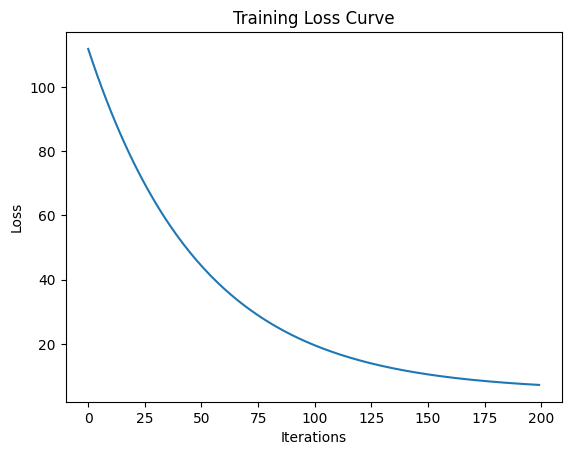

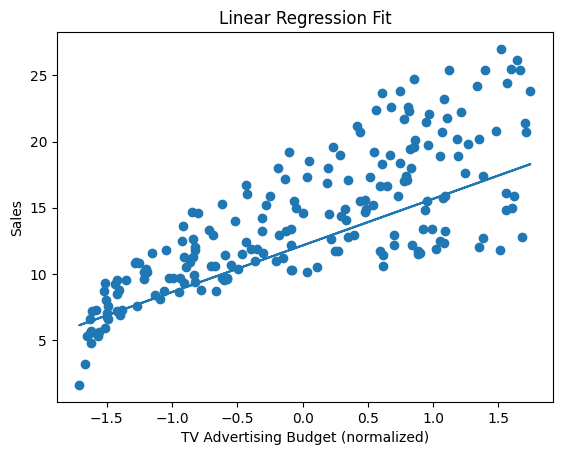

In [3]:
# Normal Method

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load real dataset
# -----------------------------

url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
data = pd.read_csv(url)

# Use only one feature for simplicity
X = data['TV'].values
y = data['sales'].values

m = len(X)

# -----------------------------
# 2. Normalize feature
# -----------------------------

X = (X - X.mean()) / X.std()

# -----------------------------
# 3. Initialize parameters
# -----------------------------

w = 0
b = 0

alpha = 0.01
iterations = 200

loss_history = []

# -----------------------------
# 4. Gradient Descent
# -----------------------------

for i in range(iterations):

    predictions = w * X + b
    errors = predictions - y

    cost = (1/(2*m)) * np.sum(errors**2)
    loss_history.append(cost)

    dj_dw = (1/m) * np.sum(errors * X)
    dj_db = (1/m) * np.sum(errors)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db


print("Learned parameters:")
print("w:", w)
print("b:", b)

# -----------------------------
# 5. Plot Loss Curve
# -----------------------------

plt.figure()
plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()


# -----------------------------
# 6. Plot Regression Fit
# -----------------------------

plt.figure()

plt.scatter(X, y)

pred_line = w * X + b
plt.plot(X, pred_line)

plt.xlabel("TV Advertising Budget (normalized)")
plt.ylabel("Sales")
plt.title("Linear Regression Fit")

plt.show()

Learned Model:
Sales = 0.0475 * TV_budget + 7.0326


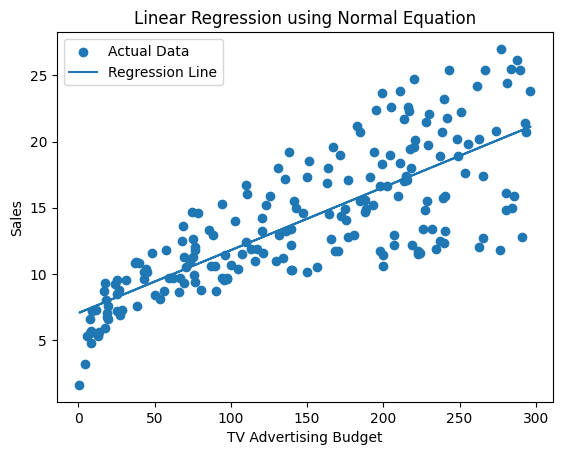

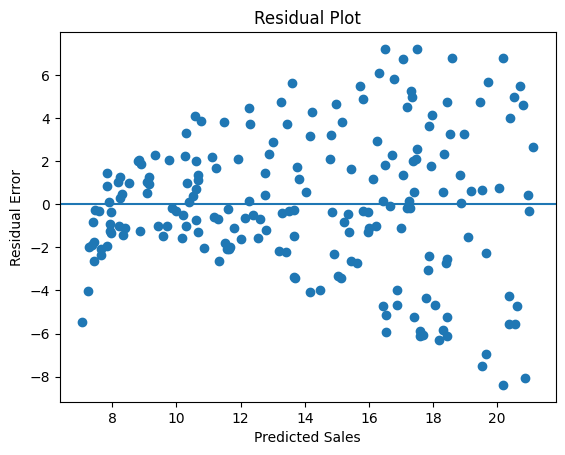

In [4]:
# Using Normal Equation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load dataset
# -----------------------------

url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
data = pd.read_csv(url)

# Use TV advertising as feature
X = data['TV'].values
y = data['sales'].values

m = len(X)

# -----------------------------
# 2. Create feature matrix
# -----------------------------

X_matrix = np.c_[np.ones(m), X]

# -----------------------------
# 3. Normal Equation
# θ = (XᵀX)⁻¹Xᵀy
# -----------------------------

theta = np.linalg.inv(X_matrix.T @ X_matrix) @ X_matrix.T @ y

b = theta[0]
w = theta[1]

print("Learned Model:")
print(f"Sales = {w:.4f} * TV_budget + {b:.4f}")

# -----------------------------
# 4. Predictions
# -----------------------------

y_pred = X_matrix @ theta

# -----------------------------
# 5. Plot regression line
# -----------------------------

plt.figure()

plt.scatter(X, y, label="Actual Data")
plt.plot(X, y_pred, label="Regression Line")

plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("Linear Regression using Normal Equation")
plt.legend()

plt.show()


# -----------------------------
# 6. Residual plot
# -----------------------------

residuals = y - y_pred

plt.figure()

plt.scatter(y_pred, residuals)
plt.axhline(0)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual Error")
plt.title("Residual Plot")

plt.show()